# Analyse du jeu de données

In [31]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

In [7]:
FILE_PATH = "RH_dataset.csv"

In [8]:
df = pd.read_csv(FILE_PATH, sep=';')

## Analyse exploratoire des données

In [9]:
df.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [10]:
df.describe()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000
mean,29.460739,7.934986,7.530322,11.632095,20.193947,41.767154,0.720711,1.554554,4168.404032,0.506853,1361.255858,0.031647
std,25.497874,7.549982,5.985476,9.218618,9.295469,11.014444,0.448659,0.657887,1657.829824,0.500299,794.183153,0.175062
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.000000
25%,10.590000,3.180000,2.300000,3.800000,11.000000,34.000000,0.000000,1.000000,3197.000000,0.000000,655.000000,0.000000
50%,21.219999,5.880000,6.280000,9.870000,26.000000,41.000000,1.000000,1.000000,3629.000000,1.000000,1371.000000,0.000000
75%,41.400002,10.340000,11.070000,16.320000,28.000000,49.000000,1.000000,2.000000,4511.000000,1.000000,2072.000000,0.000000
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,1.000000


In [ ]:
print(df.isnull().sum())

Famille d'emploi                0
Dernière promotion (mois)       0
Dernière augmentation (mois)    0
Début de contrat (années)       0
Ancienneté groupe (années)      0
Etablissement                   0
Âge (années)                    0
Parent                          0
Niveau hiérarchique             0
Salaire (Euros)                 0
Statut marital                  0
Véhicule                        0
matricule                       0
label                           0
dtype: int64


Nous n'avons pas de données manquantes.

## Comparaison de parcours

Affichage d'un exempe pour chaque classe:

In [38]:
resigned = df[df.iloc[:, -1] == 1].sample(1)
stayed = df[df.iloc[:, -1] == 0].sample(1)

resigned.insert(0, 'Status', 'Démission')
stayed.insert(0, 'Status', 'Resté')

profiles = pd.concat([resigned, stayed])

In [39]:
profiles

,Status,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
16181,Démission,Support,11.740000,11.36,1.59,1.59,28,27,0,1,2800,Célibataire,0,1186,1
20535,Resté,IT,26.860001,1.90,2.68,2.88,2,36,1,2,4489,Marié(e),1,1121,0


Peut être faire des analyses par Famille d'emploi \
Peut être faire des analyses par rapport a la dernière promotion

Faire une aggregration en fonction de si on démissionné ou non et mettre les deux profils médians

## Matrice de Corrélation

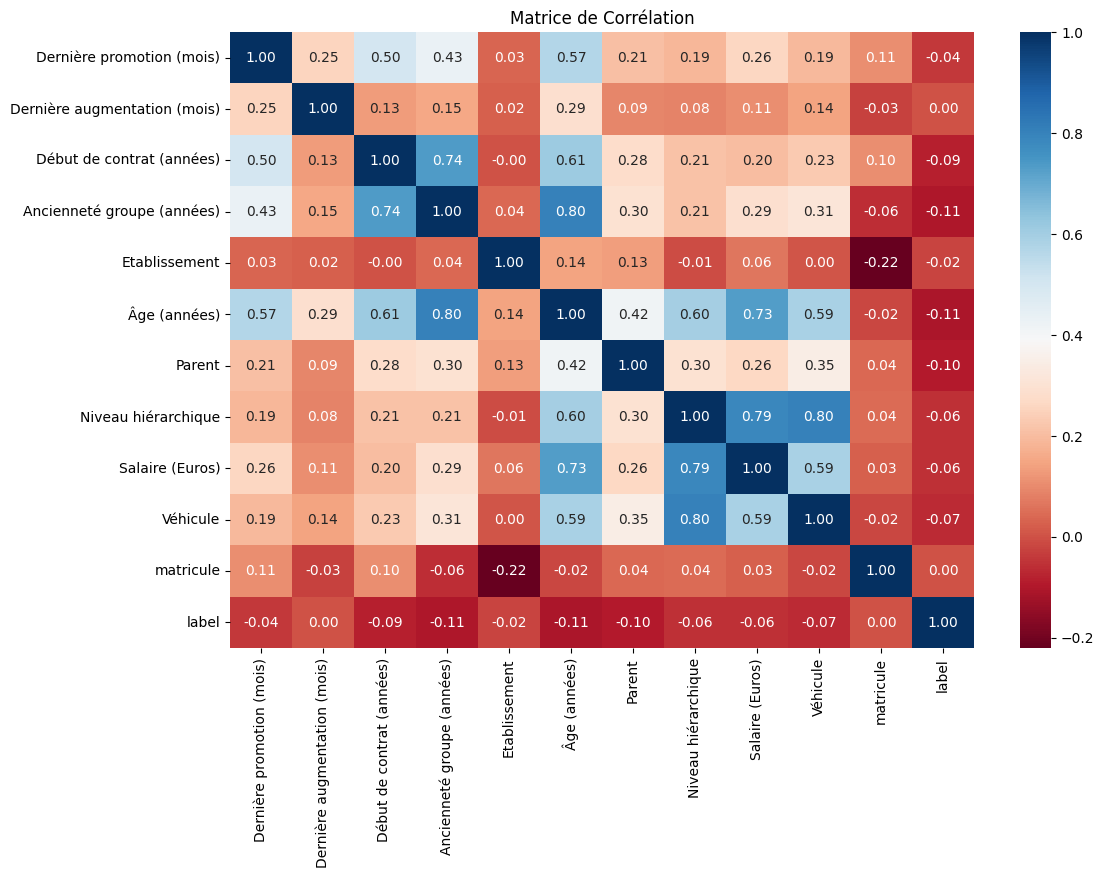

In [42]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title("Matrice de Corrélation")
plt.show()

## Distribution

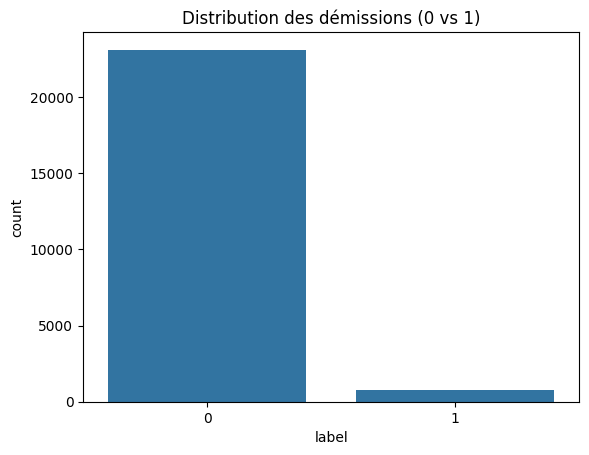

In [33]:
sns.countplot(x=df.columns[-1], data=df)
plt.title("Distribution des démissions (0 vs 1)")
plt.show()

Distribution des variables numériques

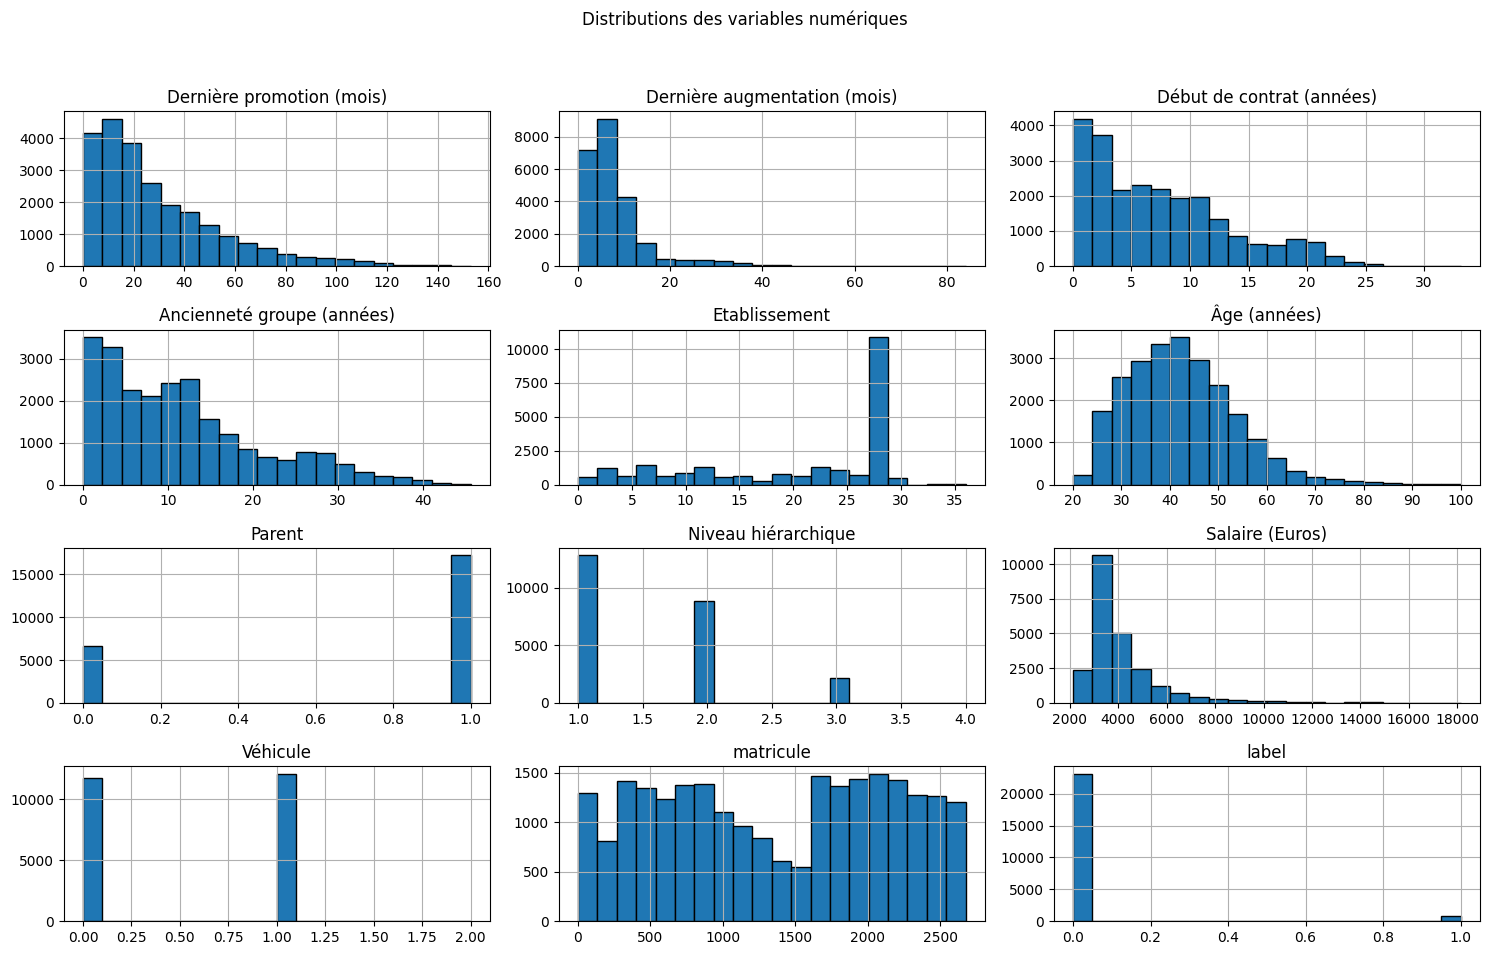

In [43]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
df[num_cols].hist(bins=20, figsize=(15, 10), layout=(-1, 3), edgecolor='black')
plt.suptitle("Distributions des variables numériques")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Beaucoup de personnes dans l'établissement 27.

Distribution de la famille d'emploi et du status marital

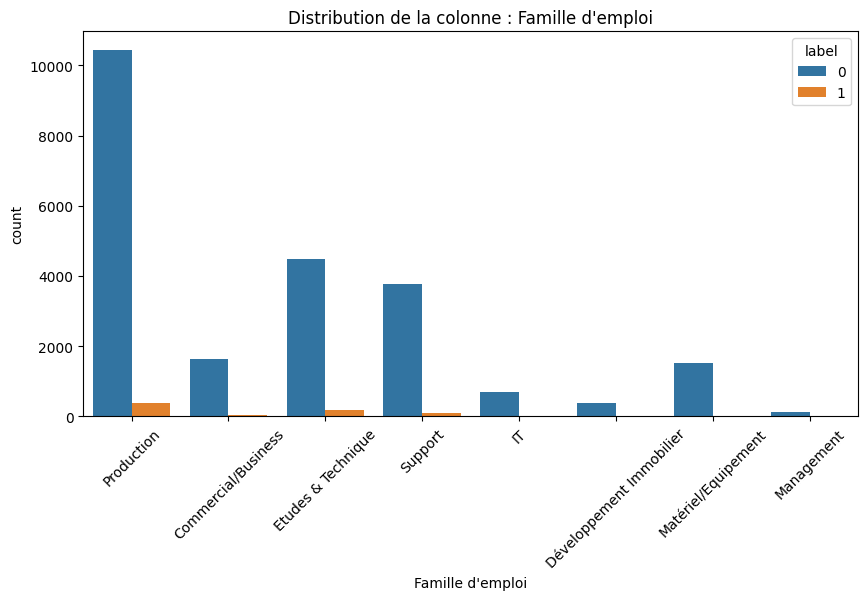

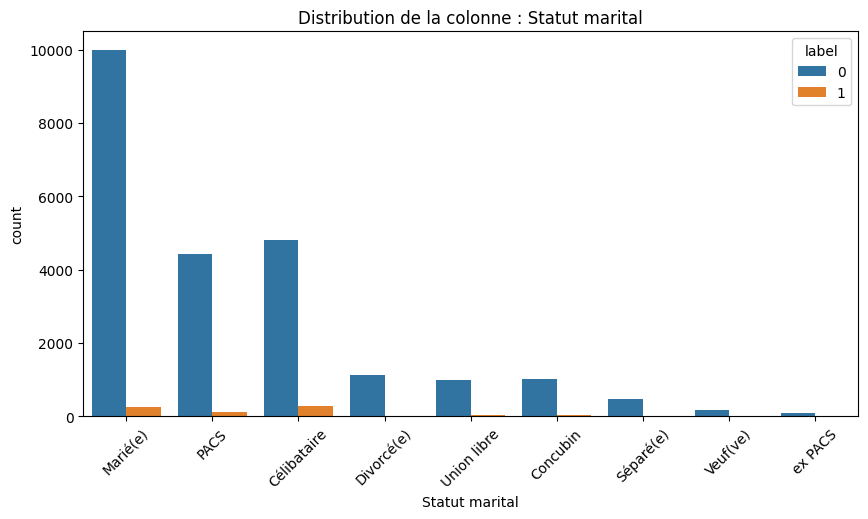

In [45]:
cat_cols = df.select_dtypes(include=['object']).columns
    
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue=df.columns[-1])
    plt.title(f"Distribution de la colonne : {col}")
    plt.xticks(rotation=45)
    plt.show()

Même analyse mais en pourcentage

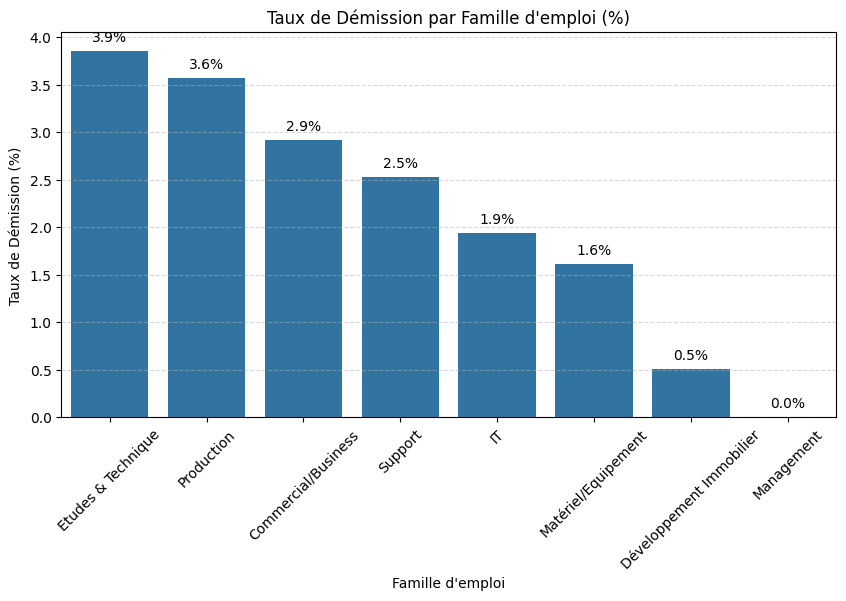

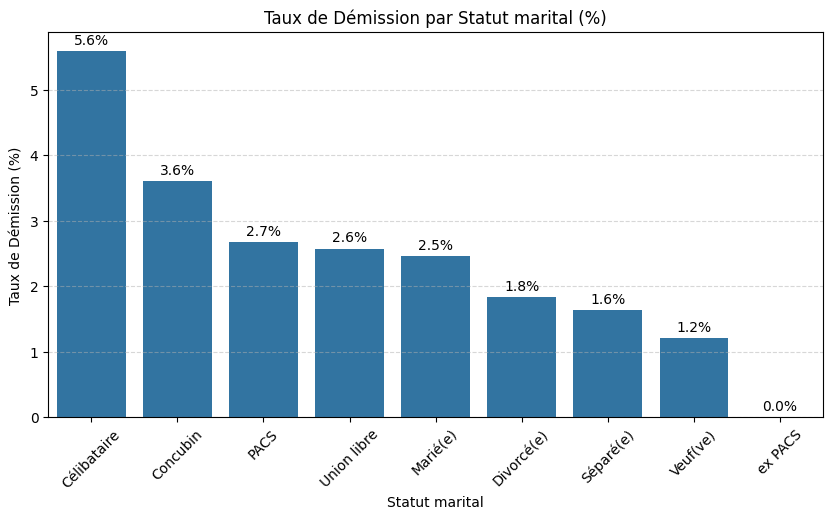

In [52]:
cat_cols = df.select_dtypes(include=['object']).columns
target = df.columns[-1]

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    
    resignation_rate = df.groupby(col)[target].mean() * 100
    
    resignation_rate = resignation_rate.sort_values(ascending=False)
    
    sns.barplot(x=resignation_rate.index, y=resignation_rate.values)
    
    plt.title(f"Taux de Démission par {col} (%)")
    plt.ylabel("Taux de Démission (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    for i, v in enumerate(resignation_rate.values):
        plt.text(i, v + 0.1, f"{v:.1f}%", ha='center')
        
    plt.show()

TODO: Distribution sur les différentes colonnes

## Plages de valeurs